## 1. Import data 

In [2]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt

In [3]:
t_eval = np.load('data/t_eval.npy', allow_pickle = True)
returns = pd.read_csv('data/returns.csv', index_col = 0, parse_dates = True)

print(len(t_eval))
returns


83


,AAPL,ABBV,AEP,AMT,AMZN,APD,AVGO,BAC,BLK,CAT,...,SLB,SO,SPG,T,TSLA,UNH,UNP,WFC,WMT,XOM
Date,,,,,,,,,,,,,,,,,,,,,
2013-02-01,-0.031422,0.018084,0.032583,0.018862,-0.004644,-0.012545,-0.044299,-0.007982,0.014580,-0.063137,...,-0.002566,0.028546,-0.008275,0.048664,-0.074129,-0.032397,0.042081,0.014265,0.011796,-0.004679
2013-03-01,0.008662,0.099438,0.049106,-0.008801,0.008365,0.008993,0.048484,0.082105,0.069012,-0.060239,...,-0.034918,0.041559,0.005168,0.021489,0.084208,0.067982,0.043121,0.053017,0.055643,0.012602
2013-04-01,0.000271,0.121536,0.055981,0.087931,-0.048751,0.006270,-0.111507,0.010617,0.043753,-0.026802,...,-0.006162,0.027538,0.116043,0.020769,0.354112,0.050322,0.038232,0.026412,0.044325,-0.012507
2013-05-01,0.015574,-0.066551,-0.115501,-0.072696,0.058869,0.082198,0.165971,0.104060,0.046554,0.019661,...,-0.018989,-0.094067,-0.067541,-0.052416,0.593717,0.044067,0.044028,0.065476,-0.037760,0.016494
2013-06-01,-0.119298,-0.032134,-0.013318,-0.061870,0.031051,-0.030543,-0.009320,-0.060351,-0.083436,-0.039342,...,-0.018937,0.015880,-0.046110,0.011649,0.093672,0.044501,0.002182,0.025443,0.001292,0.005567
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-01,0.030684,0.066755,0.021775,0.016470,-0.046413,0.062176,0.013231,0.010856,0.028467,0.032259,...,-0.093262,0.033902,0.086778,0.048106,-0.080549,0.024076,0.037234,-0.014770,0.117913,-0.005496
2024-09-01,0.018473,0.005942,0.031888,0.037234,0.042931,0.065546,0.057752,-0.026609,0.051542,0.093803,...,-0.047484,0.051096,0.009930,0.100323,0.200441,-0.009397,-0.032942,-0.026840,0.047416,0.001895
2024-10-01,-0.030902,0.031845,-0.038247,-0.085324,0.000376,0.042060,-0.012669,0.059026,0.038557,-0.038893,...,-0.039327,0.009381,0.013132,0.024249,-0.046071,-0.031585,-0.060242,0.139092,0.014751,-0.003761


## 2. PCA and Covariance Estimation

In [4]:
from sklearn.decomposition import PCA

lookback = 36
window = returns.iloc[-lookback-1:-1]
pca = PCA()
pca.fit(window)
variance_pct = pca.explained_variance_ratio_
cum_var = np.cumsum(variance_pct)
k = np.argmax(cum_var >= 0.8) + 1

Text(0.5, 1.0, 'Cross-Sectional Cumulative Variance')

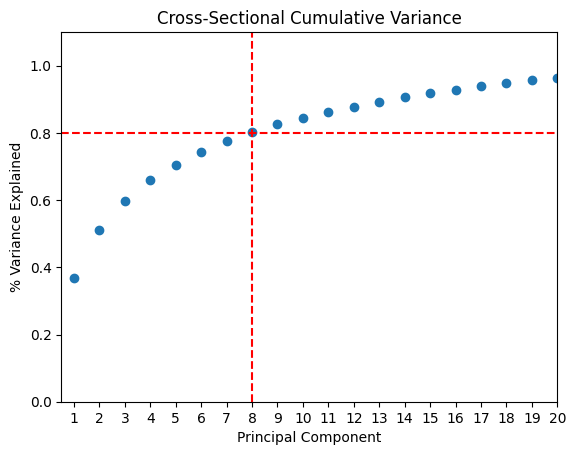

In [5]:

plt.scatter(range(1, 1 + len(cum_var)), cum_var)
plt.axhline(0.8, color = 'r', ls = '--')
plt.axvline(k, color = 'r', ls = '--')
plt.xlim(0.5,20)
plt.ylim(0,1.1)
plt.xticks(np.linspace(1,20,20))
plt.xlabel('Principal Component')
plt.ylabel('% Variance Explained')
plt.title('Cross-Sectional Cumulative Variance')



In [6]:
lookback = 36
threshold = 0.8
sigma_list = []

for t in range(lookback, len(returns)):
    # Lookback window
    window = returns.iloc[t-lookback:t]
    print(returns.index[t])
    # PCA deconstruction
    pca = PCA()
    pca.fit(window)

    cum_var = np.cumsum(pca.explained_variance_ratio_)
    k = np.argmax(cum_var >= threshold)

    B = pca.components_[:k,:]
    F = np.diag(pca.explained_variance_[:k])

    sigma_pca = B.T @ F @ B

    sample_cov = window.cov().values

    D = np.diag(np.diag(sample_cov - sigma_pca))

    sigma_t = sigma_pca + D

    sigma_list.append(sigma_t)

# Stack along axis 2
sigma = np.stack(sigma_list, axis=2)
sigma


2016-02-01 00:00:00
2016-03-01 00:00:00
2016-04-01 00:00:00
2016-05-01 00:00:00
2016-06-01 00:00:00
2016-07-01 00:00:00
2016-08-01 00:00:00
2016-09-01 00:00:00
2016-10-01 00:00:00
2016-11-01 00:00:00
2016-12-01 00:00:00
2017-01-01 00:00:00
2017-02-01 00:00:00
2017-03-01 00:00:00
2017-04-01 00:00:00
2017-05-01 00:00:00
2017-06-01 00:00:00
2017-07-01 00:00:00
2017-08-01 00:00:00
2017-09-01 00:00:00
2017-10-01 00:00:00
2017-11-01 00:00:00
2017-12-01 00:00:00
2018-01-01 00:00:00
2018-02-01 00:00:00
2018-03-01 00:00:00
2018-04-01 00:00:00
2018-05-01 00:00:00
2018-06-01 00:00:00
2018-07-01 00:00:00
2018-08-01 00:00:00
2018-09-01 00:00:00
2018-10-01 00:00:00
2018-11-01 00:00:00
2018-12-01 00:00:00
2019-01-01 00:00:00
2019-02-01 00:00:00
2019-03-01 00:00:00
2019-04-01 00:00:00
2019-05-01 00:00:00
2019-06-01 00:00:00
2019-07-01 00:00:00
2019-08-01 00:00:00
2019-09-01 00:00:00
2019-10-01 00:00:00
2019-11-01 00:00:00
2019-12-01 00:00:00
2020-01-01 00:00:00
2020-02-01 00:00:00
2020-03-01 00:00:00


array([[[ 4.25223280e-03,  4.20656078e-03,  4.55059016e-03, ...,
          5.82968451e-03,  5.82990755e-03,  5.65383365e-03],
        [ 1.67071412e-03,  1.74005823e-03,  1.89541945e-03, ...,
          8.78938923e-04,  8.19946776e-04,  7.49536121e-04],
        [-1.55335802e-04, -6.21872354e-05,  1.60097023e-04, ...,
          1.65285747e-03,  1.67141633e-03,  1.63686257e-03],
        ...,
        [ 9.31893610e-04,  9.14874124e-04,  1.01253942e-03, ...,
          2.29471098e-03,  1.96959832e-03,  2.36777540e-03],
        [-2.41710026e-04, -1.65269855e-04, -7.23254768e-05, ...,
          1.89559626e-03,  1.82135183e-03,  2.00337053e-03],
        [ 1.19435266e-03,  1.15921969e-03,  1.33890336e-03, ...,
          7.31974597e-04,  5.84061294e-04,  6.39360878e-04]],

       [[ 1.67071412e-03,  1.74005823e-03,  1.89541945e-03, ...,
          8.78938923e-04,  8.19946776e-04,  7.49536121e-04],
        [ 4.59422301e-03,  4.59589734e-03,  4.41140168e-03, ...,
          4.30101392e-03,  4.25612316e

## 3. Risk-Adjusted Alpha Allocation

In [7]:
def standardise(df: pd.DataFrame) -> pd.DataFrame:
    def standardise_row(row):
        mu = row.mean()
        sig = row.std()
        if sig == 0:
            return row - mu
        return (row - mu) / sig

    return df.apply(standardise_row, axis=1)

def normalise(df: pd.DataFrame) -> pd.DataFrame:
    def normalise_row(row):
        tot = row.abs().sum()
        return row / tot

    return df.apply(normalise_row, axis=1)

In [8]:
scores = pd.read_csv('data/factor_scores.csv', index_col = 0, parse_dates = True)
scores_n = standardise(scores)
scores_n

,AAPL,MSFT,NVDA,AVGO,CRM,JPM,BAC,GS,MS,BLK,...,PLD,AMT,EQIX,SPG,PSA,LIN,APD,NEM,FCX,SHW
Date,,,,,,,,,,,,,,,,,,,,,
2018-01-01,0.455442,0.287644,4.132708,0.895288,0.798634,0.389298,0.835593,0.433304,0.682665,0.542240,...,-0.318407,0.091055,-0.022343,-0.739163,-0.851975,-0.203055,-0.269866,-0.109847,2.670264,0.615445
2018-02-01,-0.100935,0.110585,4.311712,0.543335,0.547797,0.221708,0.588410,0.154591,0.433291,0.511081,...,-0.141316,0.064628,0.525205,-0.757846,-1.140020,-0.045899,-0.247968,-0.051016,2.108843,0.528298
2018-03-01,-0.355145,0.457459,4.612507,0.202097,0.104211,0.327834,0.866096,0.010070,0.305516,0.284565,...,0.025386,-0.104694,0.780693,-0.844483,-1.083394,-0.222888,-0.529235,-0.269014,1.231170,0.230502
2018-04-01,-0.004770,0.478929,4.288182,0.155805,0.053149,0.251535,0.763585,-0.069036,0.232589,0.212308,...,-0.284793,-0.100771,0.354473,-0.915564,-1.273038,-0.267424,-0.707368,-0.253183,1.637267,0.130733
2018-05-01,0.355365,0.270881,3.486669,0.446302,-0.063783,0.048714,0.688185,-0.240468,0.078041,0.058186,...,-0.196627,-0.108977,0.280744,-1.020281,-1.383751,-0.363360,-0.864541,-0.522327,1.871622,0.149291
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-07-01,-0.221742,0.034750,3.506592,1.800776,0.280324,-0.028116,-0.093120,0.025118,0.495666,-0.607129,...,0.404805,0.230081,-0.773770,-0.372678,-0.360927,-0.788330,-1.282005,1.215790,0.677257,0.287402
2024-08-01,0.009792,0.071273,3.585889,1.640834,1.037173,-0.533811,-0.525907,-0.422051,0.564615,-0.018389,...,1.227590,0.778933,-0.322096,-0.463078,0.473511,-0.932502,-0.920129,1.338798,0.760856,0.675303
2024-09-01,0.381589,0.502607,3.712165,1.872359,0.673077,0.210538,-0.396209,-0.055620,0.422617,-0.277347,...,0.788566,0.267840,-0.609899,-0.728726,0.051780,-0.770799,-1.007486,0.883761,0.544473,0.459645


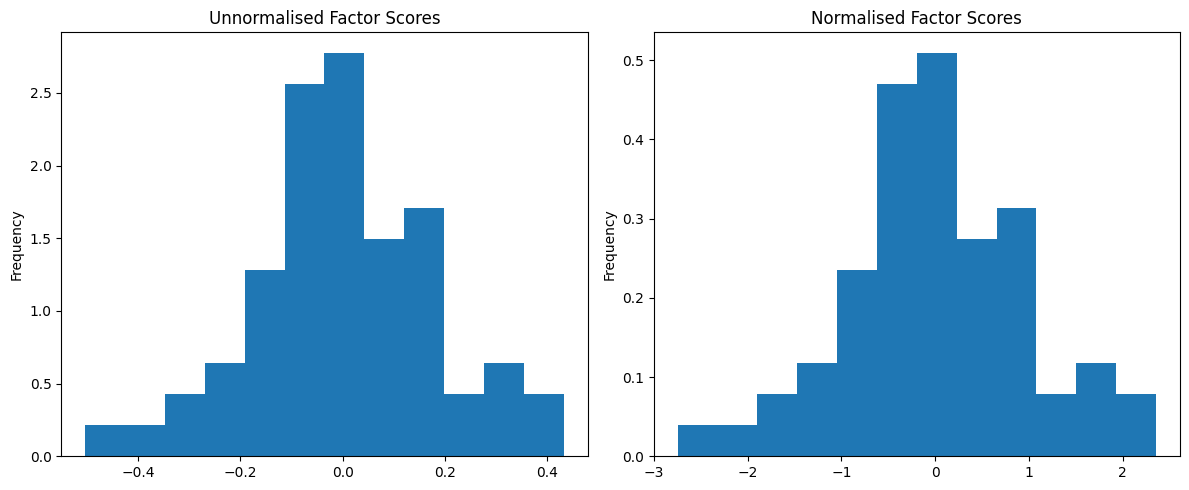

In [9]:
fig, ax = plt.subplots(1, 2, figsize = (12,5))
scores.iloc[60].plot(ax = ax[0], kind = 'hist', bins = 12, density = True)
scores_n.iloc[60].plot(ax = ax[1], kind = 'hist', bins = 12, density = True)
ax[0].set_title('Unnormalised Factor Scores')
ax[1].set_title('Normalised Factor Scores')
plt.tight_layout()

In [10]:
t_eval = scores.index
sigma_t = sigma[:,:,-len(t_eval):]
sigma_t.shape

(60, 60, 83)

In [11]:
weights_t = pd.DataFrame(
    index = t_eval, 
    columns = scores.columns
)
for i,t in enumerate(t_eval):
    mu_t = scores_n.loc[t].values
    sigma_t_i = sigma[:,:,i]

    w = np.linalg.solve(sigma_t_i, mu_t)
    w = w - w.mean() # denorm
    w = w / np.abs(w).sum() # scale exposure

    weights_t.loc[t] = w

print(weights_t.sum(axis = 1))
print(weights_t.abs().sum(axis = 1))


Date
2018-01-01   -0.0
2018-02-01    0.0
2018-03-01    0.0
2018-04-01    0.0
2018-05-01   -0.0
             ... 
2024-07-01   -0.0
2024-08-01    0.0
2024-09-01    0.0
2024-10-01   -0.0
2024-11-01   -0.0
Length: 83, dtype: object
Date
2018-01-01    1.0
2018-02-01    1.0
2018-03-01    1.0
2018-04-01    1.0
2018-05-01    1.0
             ... 
2024-07-01    1.0
2024-08-01    1.0
2024-09-01    1.0
2024-10-01    1.0
2024-11-01    1.0
Length: 83, dtype: object


In [12]:
# Calculate Risk-adjusted alpha portfolio
returns_eval = pd.read_csv('data/returns_eval.csv', index_col = 0, parse_dates = True)

ra_returns = (returns_eval * weights_t).sum(axis = 1)
ra_returns.to_csv('outputs/ra_returns.csv')

## 4. Mean-Variance Optimisation

In [18]:
!pip install cvxpy

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ----------------------- ---------------- 0.8/1.4 MB 4.8 MB/s eta 0:00:01
   ---------------------------------------- 1.4/1.4 MB 5.4 MB/s eta 0:00:00
   ---------------------------------------- 0.0/887.3 kB ? eta -:--:--
   ---------------------------------------- 887.3/887.3 kB 5.0 MB/s eta 0:00:00
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------- ----------------- 1.3/2.3 MB 6.7 MB/s eta 0:00:01
   ---------------------------------------- 2.3/2.3 MB 6.0 MB/s eta 0:00:00
   ---------------------------------------- 0.0/7.5 MB ? eta -:--:--
   ------- -------------------------------- 1.3/7.5 MB 6.7 MB/s eta 0:00:01
   -------------- ------------------------- 2.6/7.5 MB 6.3 MB/s eta 0:00:01
   --------------------- ------------------ 3.9/7.5 MB 6.3 MB/s eta 0:00:01
   ---------------------------- 


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: C:\Users\godwi\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [17]:
import cvxpy as cp

ModuleNotFoundError: No module named 'cvxpy'